# A minimal CPP analysis

The shortest complete loop in **AAanalysis**: load a dataset, run **Comparative Physicochemical Profiling (CPP)** with its defaults, and read out the physicochemical *signature* that separates the two groups — first as a ranked list, then as a feature map.

We use the domain-level γ-secretase dataset (`DOM_GSEC`: substrates vs. non-substrates) and lean on defaults throughout: CPP loads a default amino-acid scale set for you, so there is nothing to select or tune. For the broader tour (machine learning, SHAP feature impact, the comparison harness) see the **Quick start** tutorial.

**You will learn** to use the tool below — its inputs, outputs, key parameters, and how to inspect the result.

- **Tool** — `aa.SequenceFeature`, `aa.CPP`, `aa.TreeModel`, `aa.CPPPlot`
- **Input** — `df_seq` (sequences with a binary `label`)
- **Output** — `df_feat` (the CPP signature) plus a feature map
- **Best used for** — a four-step first taste of the load -> CPP -> signature loop before choosing the right setup for your own task
- **Related protocol** — [P1: CPP signature](https://aaanalysis.readthedocs.io/en/latest/generated/protocol1_cpp_signature.html)
- **Related API** — [`aa.CPP`, `aa.CPPPlot`](https://aaanalysis.readthedocs.io/en/latest/api.html#feature-engineering)

---

In [1]:
import matplotlib.pyplot as plt

import aaanalysis as aa
aa.options["verbose"] = False
aa.options["random_state"] = 42

## 1. Load a dataset

`load_dataset` returns a sequence table (`df_seq`) with the TMD bounds. Its binary `label` column is the A-vs-B grouping that CPP contrasts.

In [2]:
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()
aa.display_df(df=df_seq, n_rows=10, show_shape=True)

DataFrame shape: (100, 9)


,entry,gene,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,FXYD3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MTDH,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,PMEPA1,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,PTTG1IP,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,RELL1,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
6,P01135,TGFA,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,99,121,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
7,O43914,TYROBP,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,42,64,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
8,P05556,ITGB1,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,729,751,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
9,P16234,PDGFRA,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,527,549,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW
10,P50895,BCAM,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,549,571,TVSPQTSQAG,VAVMAVAVSVGLLLLVVAVFYCV,RRKGGPCCRQ


## 2. Run CPP

`SequenceFeature` builds the **parts** (the TMD and its juxtamembrane flanks) that CPP profiles. `CPP` then creates all *Part × Split × Scale* features over a **default scale set** — no scale selection needed — contrasts the two groups, and returns the ranked, non-redundant feature table `df_feat`.

In [3]:
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels)
aa.display_df(df=df_feat, n_rows=10, show_shape=True)

DataFrame shape: (100, 13)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,α-helix (middle),"Weights for alp...ejnowski, 1988)",0.387000,0.121000,0.121000,0.069000,0.085000,0.000000,0.000000,"27,28,29,30,31,32,33"
2,"TMD_C_JMD_C-Seg...5,7)-FAUJ880104",Shape,Side chain length,Steric parameter,"STERIMOL length...e et al., 1988)",0.382000,0.264000,0.264000,0.156000,0.156000,0.000000,0.000000,"32,33,34"
3,"TMD_C_JMD_C-Pat...,12)-ROBB760109",Conformation,β-turn (N-term),β-turn (1st residue),"Information mea...n-Suzuki, 1976)",0.377000,0.127000,-0.127000,0.062000,0.088000,0.000000,0.000000,"21,25,28,32"
4,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric poi...n et al., 1968)",0.373000,0.220000,0.220000,0.124000,0.137000,0.000000,0.000000,"33,34,35,36"
5,"TMD_C_JMD_C-Seg...5,7)-ONEK900101",Others,Unclassified (Others),ΔG values in peptides,"Delta G values ...-DeGrado, 1990)",0.373000,0.115000,0.115000,0.066000,0.113000,0.000000,0.000000,"32,33,34"
6,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal prope...d et al., 1987)",0.370000,0.218000,-0.218000,0.123000,0.169000,0.000000,0.000000,"33,34,35,36"
7,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal prope...d et al., 1987)",0.365000,0.154000,-0.154000,0.096000,0.123000,0.000000,0.000000,"27,28,29,30,31,32,33"
8,"TMD_C_JMD_C-Seg...4,5)-FINA910103",Conformation,α-helix (C-cap),"α-helix (C-terminal, inside)","Helix terminati...n et al., 1991)",0.362000,0.264000,0.264000,0.157000,0.175000,0.000000,0.000001,"33,34,35,36"
9,"TMD_C_JMD_C-Pat...,15)-QIAN880107",Conformation,α-helix,α-helix (middle),"Weights for alp...ejnowski, 1988)",0.359000,0.158000,0.158000,0.081000,0.122000,0.000000,0.000001,"25,28,32,35"
10,"TMD_C_JMD_C-Pat...,15)-MUNV940101",Energy,Free energy (folding),Free energy (α-helix),"Free energy in ...-Serrano, 1994)",0.358000,0.097000,-0.097000,0.050000,0.082000,0.000000,0.000001,"24,28,32,35"


## 3. Score feature importance

A `TreeModel` scores how much each feature helps tell the two groups apart and writes that back as the `feat_importance` column that the plots rank by.

In [4]:
X = sf.feature_matrix(df_feat, df_parts)
tm = aa.TreeModel()
tm.fit(X, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat)

## 4. Read out the signature

`CPPPlot.ranking` lists the top features — each an interpretable, residue-grounded *Part × Split × Scale* combination — which together form the physicochemical signature of the substrates.

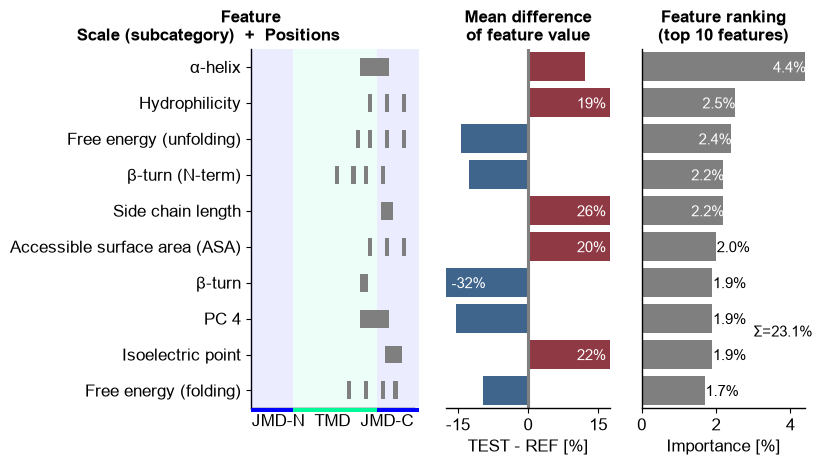

In [5]:
cpp_plot = aa.CPPPlot()
aa.plot_settings(short_ticks=True, weight_bold=False)
cpp_plot.ranking(df_feat=df_feat, n_top=10)
plt.tight_layout()
plt.show()

`CPPPlot.feature_map` then charts the *whole* signature in a single figure — every selected *Part × Split × Scale* feature placed by scale subcategory (y-axis) and residue position (x-axis), colored by the group mean difference and marked by feature importance. It is the most complete single-figure read-out of a CPP analysis.

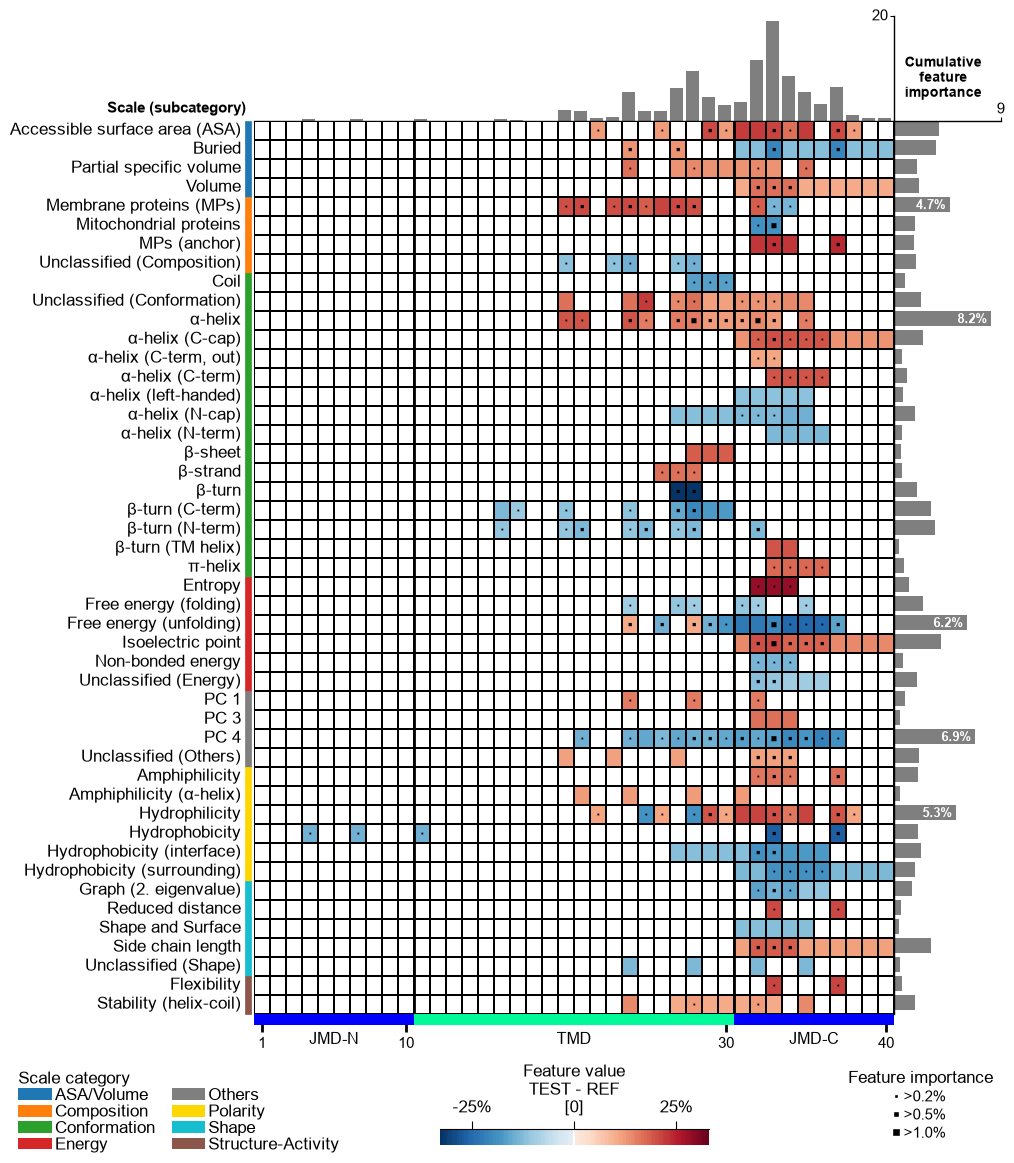

In [6]:
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat)
plt.show()

That is the whole loop: **data → CPP → signature**. To pick the right setup for *your* task — residue, domain, or protein level — see the [Prediction tasks](https://aaanalysis.readthedocs.io/en/latest/index/usage_principles/prediction_tasks.html) page, and the [Protocols](https://aaanalysis.readthedocs.io/en/latest/protocols.html) for end-to-end workflows.